# Crypto Perps Funding: Label Engineering

This notebook implements label engineering for the crypto perpetuals case
study. Labels test whether extreme premium-index conditions precede relative
perpetual-price reversal on an 8-hour research grid.

**Learning Objectives**:
- Align provider bar-open labels to the time each completed bar becomes available
- Compute forward perpetual close-price returns from that information boundary
- Create primary (8h) and variant (24h) regression labels
- Generate walk-forward CV splits respecting the 24/7 crypto calendar
- Evaluate label quality with IC analysis against a raw premium z-score

**Book Reference**: Chapter 7, Section 7.2 (Label Engineering)

**Prerequisites**: `config/setup.yaml` (canonical strategy spec) and
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) (feasibility evidence
against `setup.yaml`).

In [1]:
"""Crypto Perps Funding: Label Engineering."""

import warnings
from datetime import timedelta
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import spearmanr

from data import load_crypto_perps, load_crypto_premium
from utils.cv_splits import generate_cv_splits, make_wf_config
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE

warnings.filterwarnings("ignore")


def _numeric(value: object, default: float = 0.0) -> float:
    if value is None:
        return default
    return float(cast(int | float, value))

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
START_DATE = "2020-01-01"
MAX_SYMBOLS = 0

In [3]:
# Configuration
CASE_DIR = get_case_study_dir("crypto_perps_funding")
LABELS_DIR = CASE_DIR / "labels"

# Date range
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
HOLDOUT_START = "2024-01-01"

# Label parameters
PRIMARY_HORIZON = 1  # 1 bar = 8 hours
VARIANT_HORIZON = 3  # 3 bars = 24 hours
ZSCORE_LOOKBACK = 42  # 42 bars = 14 days; differs from 7d in baseline checkpoint (which is for feature engineering, not IC test)
HAC_MAXLAGS = 3  # one 24-hour cycle of 8-hour IC observations
BAR_HOURS = 8

print(f"Date range: {START_DATE} to {END_DATE}")

Date range: 2020-01-01 to 2025-12-31


## 1. Load Completed 8H Bars on Their Availability Clock

Binance kline files label each row with its bar-open time. The premium-index
close and the resampled perpetual close are only known when that 8-hour bar
completes. We therefore advance both timestamps by eight hours before joining,
labeling, splitting, or saving. The resulting `timestamp` is the information
boundary at which the feature and current close are jointly available.

The premium index is a predictor, not the realized funding payment. Actual
funding rates also contain an interest component and exchange-specific clamps;
funding cash flows require the historical funding-rate series downstream.

In [4]:
premium_raw = load_crypto_premium(
    frequency="8h",
    start_date=START_DATE,
    end_date=END_DATE,
)
premium_8h = premium_raw.with_columns(
    (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
).sort(["symbol", "timestamp"])

perps_raw = load_crypto_perps(
    frequency="8h",
    start_date=START_DATE,
    end_date=END_DATE,
)
perps_8h = perps_raw.with_columns(
    (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
).sort(["symbol", "timestamp"])

end_exclusive = pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC") + pl.duration(days=1)
premium_8h = premium_8h.filter(pl.col("timestamp") < end_exclusive)
perps_8h = perps_8h.filter(pl.col("timestamp") < end_exclusive)

assert (
    premium_8h["timestamp"].min() - premium_raw["timestamp"].min()
).total_seconds() == BAR_HOURS * 3600
assert (
    perps_8h["timestamp"].min() - perps_raw["timestamp"].min()
).total_seconds() == BAR_HOURS * 3600

n_assets = premium_8h["symbol"].n_unique()

print(f"Premium data: {len(premium_8h):,} rows, {n_assets} assets")
print(f"Perps data:   {len(perps_8h):,} rows, {perps_8h['symbol'].n_unique()} assets")
print(f"Availability period: {premium_8h['timestamp'].min()} to {premium_8h['timestamp'].max()}")

Premium data: 107,821 rows, 19 assets
Perps data:   108,298 rows, 19 assets
Availability period: 2020-01-01 08:00:00+00:00 to 2025-12-31 16:00:00+00:00


### Verify Information-Boundary Alignment

Completed-bar availability remains on the 00:00, 08:00, and 16:00 UTC grid.
A deviation would misalign predictors, label starts, and execution.

In [5]:
hours = premium_8h["timestamp"].dt.hour().unique().sort().to_list()
assert set(hours) == {0, 8, 16}, f"Unexpected hours: {hours}"
print(f"Completed-bar alignment verified: hours = {hours}")

# Check for gaps: exact-horizon labels below require 8-hour spacing.
gap_check = (
    premium_8h.sort(["symbol", "timestamp"])
    .with_columns((pl.col("timestamp").diff().over("symbol")).alias("dt"))
    .filter(pl.col("dt").is_not_null())
)
gap_hours = gap_check["dt"].dt.total_hours()
median_gap = gap_hours.median()
max_gap = gap_hours.max()
print(f"Timestamp gaps: median={median_gap}h, max={max_gap}h")
if _numeric(max_gap) > 24:
    n_large_gaps = gap_check.filter(pl.col("dt").dt.total_hours() > 24).shape[0]
    print(f"  Warning: {n_large_gaps} gaps > 24h (possible exchange outages)")
n_irregular_gaps = gap_check.filter(pl.col("dt") != pl.duration(hours=BAR_HOURS)).height
print(f"  Irregular gaps excluded from exact-horizon labels: {n_irregular_gaps}")

Completed-bar alignment verified: hours = [0, 8, 16]
Timestamp gaps: median=8.0h, max=104h
  Irregular gaps excluded from exact-horizon labels: 61


## 2. Listing-Time Membership Within a Fixed Research Universe

Tokens listed after the data start date must only appear from their actual
listing date onward. This prevents pre-listing backfill, but it does not make
the 19-symbol universe point-in-time: the symbol list was selected as a fixed
research panel and does not represent every contract available at each date.

In [6]:
# Determine first observation date per asset
listing_dates = (
    premium_8h.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
        pl.len().alias("n_bars"),
    )
    .sort("first_date")
)

print("Asset listing dates:")
for row in listing_dates.iter_rows(named=True):
    print(
        f"  {row['symbol']:<12} {row['first_date'].date()} to {row['last_date'].date()} ({row['n_bars']:,} bars)"
    )

# Flag late-listers (appeared after data start)
data_start = premium_8h["timestamp"].min()
late_listers = (
    listing_dates.filter(pl.col("first_date") > data_start).select("symbol")["symbol"].to_list()
)

if late_listers:
    print(f"\nLate-listed assets (no pre-listing backfill): {late_listers}")
else:
    print("\nAll assets present from data start.")

print("Universe limitation: fixed 19-symbol research panel, not a PIT liquidity-ranked universe")

Asset listing dates:
  BTCUSDT      2020-01-01 to 2025-12-31 (6,554 bars)
  ETHUSDT      2020-01-01 to 2025-12-31 (6,554 bars)
  XRPUSDT      2020-01-06 to 2025-12-31 (6,541 bars)
  LINKUSDT     2020-01-17 to 2025-12-31 (6,505 bars)
  ADAUSDT      2020-01-31 to 2025-12-31 (6,463 bars)
  ATOMUSDT     2020-02-07 to 2025-12-31 (6,445 bars)
  BNBUSDT      2020-02-10 to 2025-12-31 (6,433 bars)
  COMPUSDT     2020-06-30 to 2025-12-31 (6,010 bars)
  DOGEUSDT     2020-07-10 to 2025-12-31 (5,980 bars)
  MKRUSDT      2020-08-13 to 2025-10-22 (5,672 bars)
  DOTUSDT      2020-08-22 to 2025-12-31 (5,852 bars)
  SOLUSDT      2020-09-14 to 2025-12-31 (5,786 bars)
  UNIUSDT      2020-09-18 to 2025-12-31 (5,774 bars)
  AVAXUSDT     2020-09-23 to 2025-12-31 (5,756 bars)
  NEARUSDT     2020-10-15 to 2025-12-31 (5,692 bars)
  AAVEUSDT     2020-10-16 to 2025-12-31 (5,687 bars)
  INJUSDT      2022-08-17 to 2025-12-31 (3,692 bars)
  APTUSDT      2022-10-19 to 2025-12-31 (3,506 bars)
  SUIUSDT      2023-05-04

## 3. Compute Labels

### Primary Label: 8H Forward Futures Close Price Return

The 8-hour forward return on the perpetual futures close price is the primary
prediction target. At each availability timestamp, the completed premium-index
bar and the current perpetual close are known; the label starts at that close
and ends at the next completed close. A high premium z-score should predict a
negative return if the price premium subsequently compresses.

### Variant Label: 24H Forward Futures Close Price Return

Three 8-hour bars (24 hours) test whether the signal persists beyond a single
research interval. If IC at 24h exceeds IC at 8h, the predictive relationship
decays more slowly and a lower decision frequency may deserve evaluation.

**Note on the 24h label**: Shifting by 3 bars creates overlapping labels;
consecutive observations share 2 of 3 bars. HAC inference must therefore use
at least two overlap lags. The primary 8h label is non-overlapping by construction,
but its IC series can still be serially dependent.

In [7]:
labels_df = (
    premium_8h.join(
        perps_8h.select(["timestamp", "symbol", "close"]),
        on=["timestamp", "symbol"],
        how="left",
    )
    .sort(["symbol", "timestamp"])
    .with_columns(
        pl.col("timestamp").shift(-PRIMARY_HORIZON).over("symbol").alias("_endpoint_8h"),
        pl.col("timestamp").shift(-VARIANT_HORIZON).over("symbol").alias("_endpoint_24h"),
        pl.col("close").shift(-PRIMARY_HORIZON).over("symbol").alias("_close_8h"),
        pl.col("close").shift(-VARIANT_HORIZON).over("symbol").alias("_close_24h"),
    )
    .with_columns(
        pl.when(pl.col("_endpoint_8h") == pl.col("timestamp") + pl.duration(hours=BAR_HOURS))
        .then(pl.col("_close_8h") / pl.col("close") - 1)
        .otherwise(None)
        .alias("fwd_ret_8h"),
        pl.when(
            pl.col("_endpoint_24h")
            == pl.col("timestamp") + pl.duration(hours=BAR_HOURS * VARIANT_HORIZON)
        )
        .then(pl.col("_close_24h") / pl.col("close") - 1)
        .otherwise(None)
        .alias("fwd_ret_24h"),
    )
    .drop(["_endpoint_8h", "_endpoint_24h", "_close_8h", "_close_24h"])
)

In [8]:
# Binary direction label for hit-rate analysis. Preserve nulls at each symbol's
# final observation; otherwise `when(null).otherwise(0)` silently creates a false
# down label with no future return.
labels_df = labels_df.with_columns(
    pl.when(pl.col("fwd_ret_8h").is_null())
    .then(None)
    .when(pl.col("fwd_ret_8h") > 0)
    .then(1)
    .otherwise(0)
    .cast(pl.Int8)
    .alias("fwd_dir_8h")
)

In [9]:
# 3-class direction with percentile-based thresholds
# (calibrated to empirical distribution, not fixed threshold)
# Calibrate only where the full 8-hour label endpoint precedes the holdout.
holdout_start = pl.lit(HOLDOUT_START).str.to_datetime().dt.replace_time_zone("UTC")
ret_8h_valid = labels_df.filter(
    pl.col("fwd_ret_8h").is_not_null()
    & (pl.col("timestamp") + pl.duration(hours=BAR_HOURS) < holdout_start)
)["fwd_ret_8h"]
p33 = _numeric(ret_8h_valid.quantile(0.33))
p67 = _numeric(ret_8h_valid.quantile(0.67))

labels_df = labels_df.with_columns(
    pl.when(pl.col("fwd_ret_8h").is_null())
    .then(None)
    .when(pl.col("fwd_ret_8h") > p67)
    .then(1)
    .when(pl.col("fwd_ret_8h") < p33)
    .then(-1)
    .otherwise(0)
    .cast(pl.Int8)
    .alias("fwd_dir_8h_3c")
)

print(f"Labels computed on {len(labels_df):,} rows")
print(f"3-class thresholds: down < {p33:.6f}, up > {p67:.6f}")

Labels computed on 107,821 rows
3-class thresholds: down < -0.008188, up > 0.008392


## 4. Label Distribution Summary

All diagnostics below are development-only. Each horizon is purged by its
own endpoint so no reported statistic reads the sealed 2024-2025 holdout.

In [10]:
# Regression label summary
dev_8h = labels_df.filter(
    pl.col("fwd_ret_8h").is_not_null()
    & (pl.col("timestamp") + pl.duration(hours=BAR_HOURS) < holdout_start)
)
dev_24h = labels_df.filter(
    pl.col("fwd_ret_24h").is_not_null()
    & (pl.col("timestamp") + pl.duration(hours=BAR_HOURS * VARIANT_HORIZON) < holdout_start)
)
ret_stats = dev_8h.select("fwd_ret_8h")
ret24_stats = dev_24h.select("fwd_ret_24h")

label_summary = pl.DataFrame(
    {
        "label": ["fwd_ret_8h (primary)", "fwd_ret_24h (variant)"],
        "N": [len(ret_stats), len(ret24_stats)],
        "mean": [ret_stats["fwd_ret_8h"].mean(), ret24_stats["fwd_ret_24h"].mean()],
        "std": [ret_stats["fwd_ret_8h"].std(), ret24_stats["fwd_ret_24h"].std()],
        "skew": [ret_stats["fwd_ret_8h"].skew(), ret24_stats["fwd_ret_24h"].skew()],
    }
)
print(label_summary)

shape: (2, 5)
┌───────────────────────┬───────┬──────────┬──────────┬──────────┐
│ label                 ┆ N     ┆ mean     ┆ std      ┆ skew     │
│ ---                   ┆ ---   ┆ ---      ┆ ---      ┆ ---      │
│ str                   ┆ i64   ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════════════╪═══════╪══════════╪══════════╪══════════╡
│ fwd_ret_8h (primary)  ┆ 66216 ┆ 0.000988 ┆ 0.034194 ┆ 1.316641 │
│ fwd_ret_24h (variant) ┆ 66040 ┆ 0.003019 ┆ 0.064367 ┆ 8.215786 │
└───────────────────────┴───────┴──────────┴──────────┴──────────┘


In [11]:
# Direction label distributions
dir_dist = (
    dev_8h.filter(pl.col("fwd_dir_8h").is_not_null())
    .group_by("fwd_dir_8h")
    .agg(pl.len().alias("count"))
    .sort("fwd_dir_8h")
    .with_columns(
        pl.when(pl.col("fwd_dir_8h") == 1)
        .then(pl.lit("Up"))
        .otherwise(pl.lit("Down"))
        .alias("class"),
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct"),
    )
)
print("Binary direction (fwd_dir_8h):")
print(dir_dist.select(["class", "count", "pct"]))

dir3_dist = (
    dev_8h.filter(pl.col("fwd_dir_8h_3c").is_not_null())
    .group_by("fwd_dir_8h_3c")
    .agg(pl.len().alias("count"))
    .sort("fwd_dir_8h_3c")
    .with_columns(
        pl.col("fwd_dir_8h_3c").replace_strict({-1: "Down", 0: "Flat", 1: "Up"}).alias("class"),
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct"),
    )
)
print("\n3-class direction (fwd_dir_8h_3c, percentile thresholds):")
print(dir3_dist.select(["class", "count", "pct"]))

Binary direction (fwd_dir_8h):
shape: (2, 3)
┌───────┬───────┬──────┐
│ class ┆ count ┆ pct  │
│ ---   ┆ ---   ┆ ---  │
│ str   ┆ u32   ┆ f64  │
╞═══════╪═══════╪══════╡
│ Down  ┆ 33051 ┆ 49.9 │
│ Up    ┆ 33165 ┆ 50.1 │
└───────┴───────┴──────┘

3-class direction (fwd_dir_8h_3c, percentile thresholds):
shape: (3, 3)
┌───────┬───────┬──────┐
│ class ┆ count ┆ pct  │
│ ---   ┆ ---   ┆ ---  │
│ str   ┆ u32   ┆ f64  │
╞═══════╪═══════╪══════╡
│ Down  ┆ 21851 ┆ 33.0 │
│ Flat  ┆ 22514 ┆ 34.0 │
│ Up    ┆ 21851 ┆ 33.0 │
└───────┴───────┴──────┘


**Interpretation**: Development-period label means are small relative to their
dispersion. The binary split is close to 50/50, and the 3-class split is
calibrated by construction. These are label-shape diagnostics, not evidence
that a premium signal is profitable.

## 5. Baseline IC: Raw Premium Z-Score vs Labels

Before any ML, measure how the simplest possible signal (rolling z-score of
the premium index) ranks forward perpetual-price returns. This is a diagnostic
baseline, not a return series and not a funding-cash-flow backtest.

**Sign convention**: For a mean-reversion signal, we expect **negative IC**:
high premium z-score predicts negative forward returns (price reverts toward
fair value). The IC is computed cross-sectionally (Spearman rank correlation
per timestamp, then averaged), not as a single pooled correlation. Newey-West
inference uses three lags to cover one full 24-hour cycle.

In [12]:
# Compute rolling z-score at 8h frequency
ic_df = (
    labels_df.sort(["symbol", "timestamp"])
    .with_columns(
        (
            (
                pl.col("premium_index_close")
                - pl.col("premium_index_close")
                .rolling_mean(window_size=ZSCORE_LOOKBACK)
                .over("symbol")
            )
            / pl.col("premium_index_close")
            .rolling_std(window_size=ZSCORE_LOOKBACK)
            .over("symbol")
            .clip(lower_bound=1e-8)
        )
        .clip(-10, 10)
        .alias("premium_zscore")
    )
    .filter(pl.col("fwd_ret_8h").is_not_null() & pl.col("premium_zscore").is_not_null())
    .filter(pl.col("timestamp") + pl.duration(hours=BAR_HOURS) < holdout_start)
)

In [13]:
# Cross-sectional IC per timestamp (Spearman rank correlation)
ic_values = []
for ts, group in ic_df.group_by("timestamp"):
    if len(group) < 5:
        continue
    zscore = group["premium_zscore"].to_numpy()
    ret = group["fwd_ret_8h"].to_numpy()
    ic, _ = spearmanr(zscore, ret)
    if not np.isnan(ic):
        ic_values.append({"timestamp": ts[0], "ic": ic})

In [14]:
if ic_values:
    ic_series = pl.DataFrame(ic_values).sort("timestamp")
    ic_stats = compute_ic_hac_stats(ic_series, ic_col="ic", maxlags=HAC_MAXLAGS)
    mean_ic = float(ic_stats["mean_ic"])
    std_ic = float(ic_series["ic"].std())
    t_stat = float(ic_stats["t_stat"])
    naive_t = float(ic_stats["naive_t_stat"])
    p_value = float(ic_stats["p_value"])

    print(
        "Baseline IC (premium z-score vs 8h forward price return, "
        f"label endpoints before {HOLDOUT_START}):"
    )
    print(f"  Mean IC:  {mean_ic:.4f}")
    print(f"  Std IC:   {std_ic:.4f}")
    print(f"  HAC t({HAC_MAXLAGS} lags): {t_stat:.2f} (p={p_value:.4g})")
    print(f"  Naive t:  {naive_t:.2f}")
    print(f"  N periods: {len(ic_series):,}")
    print(
        f"  Sign: {'Reversal (negative IC)' if _numeric(mean_ic) < 0 else 'Momentum (positive IC)'}"
    )
    baseline_ic = _numeric(mean_ic)
    baseline_t = _numeric(t_stat)
    baseline_p = p_value
else:
    print("Insufficient data for IC calculation")
    baseline_ic = 0.0
    baseline_t = 0.0
    baseline_p = 1.0

Baseline IC (premium z-score vs 8h forward price return, label endpoints before 2024-01-01):
  Mean IC:  -0.0387
  Std IC:   0.2857
  HAC t(3 lags): -8.94 (p=0)
  Naive t:  -8.80
  N periods: 4,232
  Sign: Reversal (negative IC)


### Development-Period Label and Baseline Diagnostics

The upper panel compares label scale without hiding the much wider 24-hour
tails. The lower panel shows whether the premium-reversal relationship is
persistent or concentrated in a short subperiod.

In [15]:
dispersion = pl.DataFrame(
    {
        "horizon": ["8h", "24h"],
        "std": [
            _numeric(ret_stats["fwd_ret_8h"].std()),
            _numeric(ret24_stats["fwd_ret_24h"].std()),
        ],
        "iqr": [
            _numeric(ret_stats["fwd_ret_8h"].quantile(0.75))
            - _numeric(ret_stats["fwd_ret_8h"].quantile(0.25)),
            _numeric(ret24_stats["fwd_ret_24h"].quantile(0.75))
            - _numeric(ret24_stats["fwd_ret_24h"].quantile(0.25)),
        ],
    }
)

In [16]:
def _plot_dispersion(ax):
    x = np.arange(len(dispersion))
    width = 0.34
    ax.bar(
        x - width / 2,
        dispersion["std"].to_numpy() * 100,
        width,
        color=COLORS["blue"],
        label="Standard deviation",
    )
    ax.bar(
        x + width / 2,
        dispersion["iqr"].to_numpy() * 100,
        width,
        color=COLORS["amber"],
        label="Interquartile range",
    )
    ax.set_xticks(x, dispersion["horizon"].to_list())
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Return dispersion (%)")
    ax.set_title("The 24-hour label widens the return distribution")
    ax.legend()

In [17]:
def _plot_ic(ax):
    if not ic_values:
        ax.set_visible(False)
        return
    ic_plot = ic_series.with_columns(
        pl.col("ic").rolling_mean(window_size=90, min_samples=30).alias("ic_30d")
    ).drop_nulls("ic_30d")
    ax.plot(
        ic_plot["timestamp"].to_list(),
        ic_plot["ic_30d"].to_numpy(),
        color=COLORS["blue"],
        label="30-day rolling mean IC",
    )
    ax.axhline(
        baseline_ic,
        color=COLORS["amber"],
        linestyle="--",
        label=f"Development mean {baseline_ic:+.3f}",
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
    ax.set_ylabel("Cross-sectional Spearman IC")
    ax.set_title("Premium reversal varies through the development period")
    ax.legend()

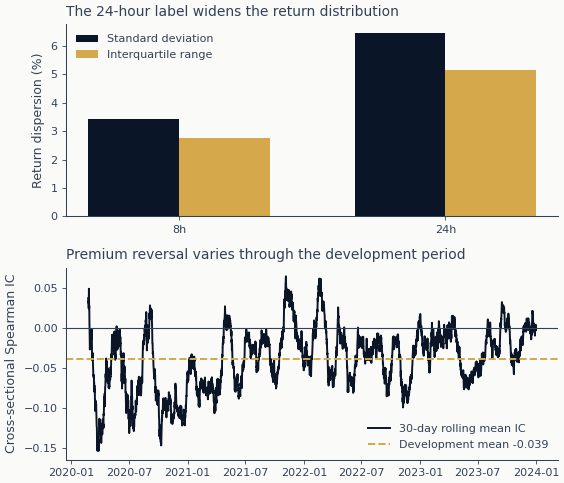

In [18]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"])
_plot_dispersion(axes[0])
_plot_ic(axes[1])
fig.tight_layout()
plt.show()

## 6. Generate CV Configuration

Walk-forward splits from `setup.yaml`. The crypto 24/7 calendar has no
weekend gaps, so date-based splitting works directly on timestamps.

In [19]:
cv_config = make_wf_config("crypto_perps_funding", label_horizon="8H", date_col="timestamp")
print("CV Configuration:")
print(f"  n_splits:      {cv_config.n_splits}")
print(f"  train_size:    {cv_config.train_size}")
print(f"  test_size:     {cv_config.test_size}")
print(f"  embargo:       {cv_config.embargo_td}")
print(f"  label_horizon: {cv_config.label_horizon}")
print(f"  timestamp_col: {cv_config.timestamp_col}")
print(f"  calendar:      {cv_config.calendar_id or '24/7 (no exchange calendar)'}")

CV Configuration:
  n_splits:      2
  train_size:    2Y
  test_size:     1Y
  embargo:       None
  label_horizon: 0 days 08:00:00
  timestamp_col: timestamp
  calendar:      24/7 (no exchange calendar)


In [20]:
label_horizons = {
    "fwd_ret_8h": 8,
    "fwd_ret_24h": 24,
    "fwd_dir_8h": 8,
    "fwd_dir_8h_3c": 8,
}
holdout_boundary = pl.Series([HOLDOUT_START]).str.to_datetime().dt.replace_time_zone("UTC").item()
split_summary = []
for label_id, horizon_hours in label_horizons.items():
    label_frame = labels_df.select("timestamp", label_id).drop_nulls(label_id)
    label_splits = generate_cv_splits(
        label_frame,
        case_study_id=CASE_STUDY_ID,
        label_buffer=f"{horizon_hours}H",
        date_col="timestamp",
    )
    latest_val_end = max(split["val_end"] for split in label_splits)
    assert latest_val_end + timedelta(hours=horizon_hours) < holdout_boundary
    split_summary.append(
        {
            "label": label_id,
            "folds": len(label_splits),
            "latest_val_end": latest_val_end,
            "latest_label_endpoint": latest_val_end + timedelta(hours=horizon_hours),
        }
    )

In [21]:
print("Endpoint-sealed validation windows:")
pl.DataFrame(split_summary)

Endpoint-sealed validation windows:


label,folds,latest_val_end,latest_label_endpoint
str,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""fwd_ret_8h""",2,2023-12-31 08:00:00 UTC,2023-12-31 16:00:00 UTC
"""fwd_ret_24h""",2,2023-12-30 16:00:00 UTC,2023-12-31 16:00:00 UTC
"""fwd_dir_8h""",2,2023-12-31 08:00:00 UTC,2023-12-31 16:00:00 UTC
"""fwd_dir_8h_3c""",2,2023-12-31 08:00:00 UTC,2023-12-31 16:00:00 UTC


### Label Autocorrelation

The primary label does not overlap, but its cross-sectional mean can remain
serially dependent. ACF is diagnostic only; the IC inference above uses HAC
regardless of whether selected lags look small.

In [22]:
if ic_values:
    from statsmodels.tsa.stattools import acf as _acf

    _label_ts = (
        dev_8h.sort("timestamp")
        .group_by("timestamp")
        .agg(pl.col("fwd_ret_8h").mean())
        .sort("timestamp")
    )
    _label_acf = _acf(_label_ts["fwd_ret_8h"].to_numpy(), nlags=9, fft=True)
    print("Label ACF (fwd_ret_8h, cross-sectional mean):")
    for lag in [1, 3, 9]:
        if lag < len(_label_acf):
            print(f"  Lag {lag} ({lag * 8}h): {_label_acf[lag]:.3f}")

Label ACF (fwd_ret_8h, cross-sectional mean):
  Lag 1 (8h): -0.003
  Lag 3 (24h): -0.102
  Lag 9 (72h): -0.027


## 7. Save Artifacts

Output contract:
- `labels/fwd_ret_8h.parquet`: Primary regression label
- `labels/fwd_ret_24h.parquet`: 24H variant label
- `labels/fwd_dir_8h.parquet`: Binary direction label
- `labels/fwd_dir_8h_3c.parquet`: 3-class direction label
- `cv_config.json`: Walk-forward CV splits

In [23]:
KEY_COLS = ["timestamp", "symbol"]

LABELS_DIR.mkdir(parents=True, exist_ok=True)

# Save labels
for label_id in ["fwd_ret_8h", "fwd_ret_24h", "fwd_dir_8h", "fwd_dir_8h_3c"]:
    label_df = labels_df.select(KEY_COLS + [label_id]).drop_nulls()
    assert label_df.select(KEY_COLS).is_duplicated().sum() == 0
    label_df = label_df.sort(KEY_COLS)
    label_df.write_parquet(LABELS_DIR / f"{label_id}.parquet")
    print(f"Saved {label_id}.parquet ({len(label_df):,} rows)")

assert labels_df.select(pl.col("fwd_ret_8h").is_null().sum()).item() == (
    labels_df.select(pl.col("fwd_dir_8h").is_null().sum()).item()
)
assert labels_df.select(pl.col("fwd_ret_8h").is_null().sum()).item() == (
    labels_df.select(pl.col("fwd_dir_8h_3c").is_null().sum()).item()
)

# Save CV config with a stable trailing newline for clean re-execution.
cv_path = CASE_DIR / "config" / "cv_config.json"
cv_path.parent.mkdir(parents=True, exist_ok=True)
cv_path.write_text(cv_config.model_dump_json(indent=2) + "\n")
print(f"Saved cv_config.json (n_splits={cv_config.n_splits})")

Saved fwd_ret_8h.parquet (107,673 rows)
Saved fwd_ret_24h.parquet (107,497 rows)
Saved fwd_dir_8h.parquet (107,673 rows)
Saved fwd_dir_8h_3c.parquet (107,673 rows)
Saved cv_config.json (n_splits=2)


## Key Takeaways

1. **Labels predict perpetual close-price returns**: The prediction target is
   the 8-hour forward price return, not a total return that includes funding
   cash flows. The development-period premium z-score has a negative baseline
   IC; HAC inference reports its uncertainty without claiming profitability.

2. **Availability time is the label boundary**: Provider rows are labelled by
   bar-open time, so both premium and perpetual timestamps move forward eight
   hours before label construction. The feature and current close are then
   jointly available at `timestamp`, and the label begins from that boundary.

3. **24H variant tests signal persistence**: The 24-hour label overlaps across
   adjacent rows and requires horizon-aware HAC inference. A slower relationship
   may justify evaluating fewer decisions, but cost savings remain a backtest question.

4. **Universe scope remains limited**: Late-listed tokens enter only when data
   begins, so there is no pre-listing backfill. The fixed 19-symbol panel is not
   a point-in-time liquidity-ranked universe and can still carry selection bias.

**Next**: `03_financial_features.py` for premium, price, liquidity, and volatility
features; `04_model_based_features.py` for GJR-GARCH and HMM regime features.